# 02 · ตารางรายวัน: input, target และการแบ่งข้อมูล

```
ระดับน้ำรายชั่วโมง ──► ทำความสะอาด ──► สูงสุดรายวัน ──► − ตลิ่ง ──► ระยะจากตลิ่ง 6 สถานี ─┐
ฝน ERA5 รายชั่วโมง ──► เฉลี่ยลุ่มน้ำ ──► ฝนรายวัน ──────────────────────────────────────┼──► 7 features ต่อวัน
                                                                                         │
ฝนอนาคต t+1…t+h ──► train: ERA5 ที่ตกจริง / validation, test: พยากรณ์ GFS ────────────► 5 ค่า (h = 1…5)
target ──► ระดับน้ำสูงสุดของ X.44 วันที่ t+1 … t+5 (ม.รทก.)
```

In [1]:
import matplotlib.pyplot as plt
import numpy
import pandas

from mojito import config, features, minimal

plt.rcParams.update({
    "font.family": ["Noto Sans Thai", "DejaVu Sans"],
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ขั้นตอนทั้งหมดอยู่ใน mojito/minimal.py (เว็บใช้ชุดเดียวกัน) notebook นี้เรียกทีละขั้นให้เห็นผล
RAW = config.RAW_DIR
PROCESSED = config.DATA_DIR / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)
HORIZONS = minimal.HORIZONS  # 1..5 วัน
STATIONS = minimal.STATIONS
X44_BANK = config.BANK_LEVEL_M["X.44"]
print("train ถึง", minimal.TRAIN_END, "· validation ถึง", minimal.VALIDATION_END)
SPLIT_COLORS = {"train": "#4c72b0", "validation": "#dd8452", "test": "#c44e52"}

ALL_STATIONS = list(config.WATERLEVEL_STATIONS)  # ไฟล์มี 9 สถานี ใช้เป็น input 6 สถานี
waterlevel_raw = pandas.read_parquet(RAW / "waterlevel_tele.parquet")
era5 = pandas.read_parquet(RAW / "era5_hourly.parquet")
nwp_rain = pandas.read_parquet(RAW / "nwp_rain_previous_runs.parquet")

train ถึง 2024-12-31 · validation ถึง 2025-09-30


## 1 · ทำความสะอาดระดับน้ำรายชั่วโมง
(`features.clean_waterlevel`)
- ค่า ≥ 999 (เช่น 999999) = ไม่มีข้อมูล → ว่าง
- **spike**: ค่าที่ห่างจาก median 7 ชั่วโมงรอบตัวเกิน 1 ม. → ว่าง (น้ำจริงขึ้นไม่เกิน ~0.5 ม./ชม.)
  และ SLA005 (ทะเลสาบ) ที่เกิน 4 ม. → ว่าง
- ช่องว่างสั้น ≤ 6 ชั่วโมง → เติมด้วยเส้นตรง
- วันที่มีข้อมูลน้อยกว่า 12 ชั่วโมง → ค่ารายวันเป็นว่าง

ทำความสะอาดครบ 9 สถานีในไฟล์เพื่อใช้เทียบในหัวข้อ 2 และ 7 (ทำทีละสถานี ผลของ 6 สถานีที่ใช้จึงเท่ากับทำแยก)

In [2]:
hourly_all, cleaning_report = features.clean_waterlevel(waterlevel_raw)
hourly = hourly_all[STATIONS]
cleaning_report.loc[ALL_STATIONS].rename(columns={
    "sentinel_removed": "ค่า ≥ 999 ที่ลบ (แถว)", "spikes_removed": "spike ที่ลบ (ชม.)",
    "hours_gap_filled": "ชม. ที่เติมช่องว่าง", "hours_valid": "ชม. ที่ใช้ได้",
})

,ค่า ≥ 999 ที่ลบ (แถว),spike ที่ลบ (ชม.),ชม. ที่เติมช่องว่าง,ชม. ที่ใช้ได้
station_code,,,,
X.44,0,0,6171,56718
X.90,0,2,6204,56629
X.173A,0,2,6171,56711
X.174,0,4,6196,56625
SLA002,15562,189,3886,101177
SLA007,0,1,1828,97473
SLA005,0,315,2929,83979
ONE037,2,0,1827,31841
ONE038,0,0,25,30274


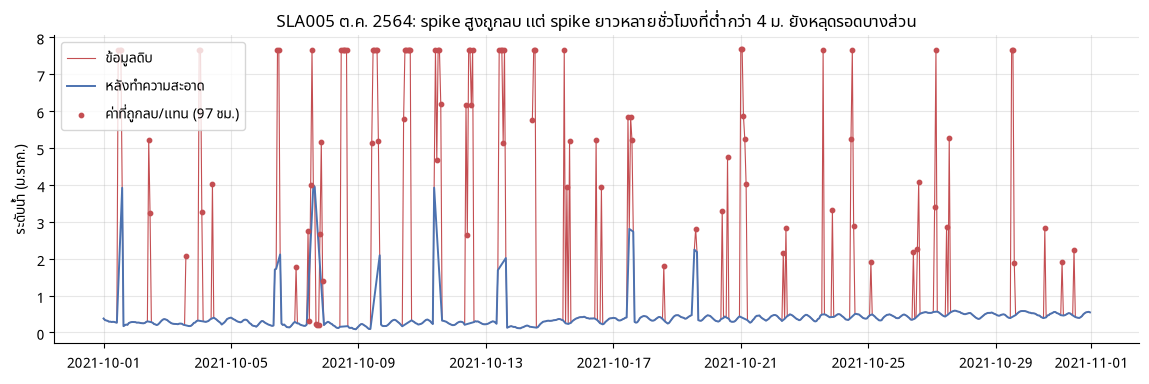

In [3]:
# ก่อน / หลังทำความสะอาด: SLA005 (ทะเลสาบ) เดือนที่มี spike มากที่สุด
station, window = "SLA005", slice("2021-10-01", "2021-10-31")
raw_hourly = (
    waterlevel_raw[(waterlevel_raw["station_code"] == station) & (waterlevel_raw["waterlevel_msl"].abs() < 999)]
    .set_index("timestamp")["waterlevel_msl"].resample("h").mean()
)
raw_hourly.index = raw_hourly.index.tz_localize(None)
raw_part, clean_part = raw_hourly.loc[window], hourly_all[station].loc[window]
removed = raw_part[(raw_part - clean_part.reindex(raw_part.index)).abs() > 0.5]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(raw_part.index, raw_part, color="#c44e52", lw=0.8, label="ข้อมูลดิบ")
ax.plot(clean_part.index, clean_part, color="#4c72b0", lw=1.4, label="หลังทำความสะอาด")
ax.scatter(removed.index, removed, color="#c44e52", s=10, zorder=3, label=f"ค่าที่ถูกลบ/แทน ({len(removed)} ชม.)")
ax.set_ylabel("ระดับน้ำ (ม.รทก.)")
ax.set_title(f"{station} ต.ค. 2564: spike สูงถูกลบ แต่ spike ยาวหลายชั่วโมงที่ต่ำกว่า 4 ม. ยังหลุดรอดบางส่วน")
ax.legend(loc="upper left")
plt.show()

- สถานีของกรมชลประทาน (X.*) ข้อมูลสะอาด แทบไม่มี spike แต่มีชั่วโมงที่ขาดเป็นช่วงสั้นๆ จำนวนมาก (เติมได้ ~6,000 ชม.)
- **SLA005** มี spike ยาวหลายชั่วโมงติดกัน median 7 ชั่วโมงจึงจับได้ไม่หมด — ค่าที่ต่ำกว่าเพดาน 4 ม. ยังหลงเหลือ
  เป็นเหตุผลหนึ่งที่ SLA005 สัมพันธ์กับ X.44 ต่ำ (หัวข้อ 7)
- **SLA002** มีค่า 999999 กว่า 15,000 แถว (ไม่ได้ใช้)

## 2 · ปัญหาที่พบในข้อมูล: ช่วงที่ขาดหาย

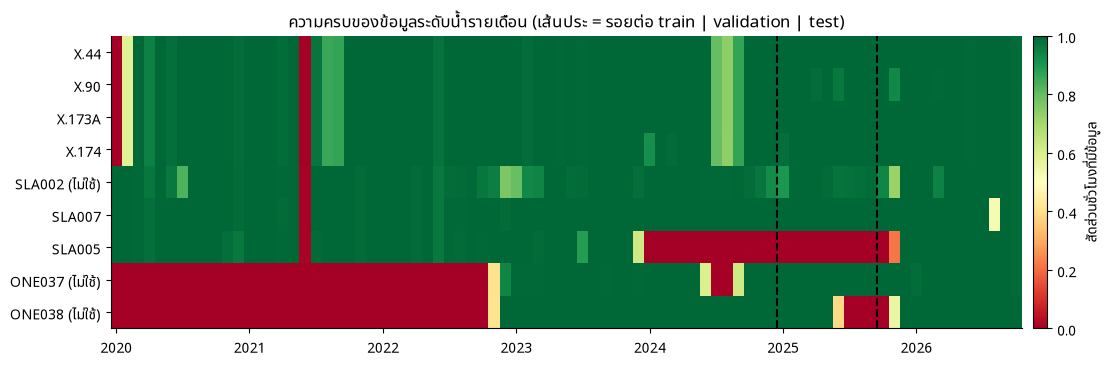

In [4]:
coverage = hourly_all.loc["2020":, ALL_STATIONS].notna().resample("MS").mean()
fig, ax = plt.subplots(figsize=(14, 3.8))
image = ax.imshow(coverage.T.to_numpy(), aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")
ax.set_yticks(range(len(ALL_STATIONS)), [s + ("" if s in STATIONS else " (ไม่ใช้)") for s in ALL_STATIONS])
january = [i for i, month in enumerate(coverage.index) if month.month == 1]
ax.set_xticks(january, [str(coverage.index[i].year) for i in january])
ax.grid(False)
for split_end in (minimal.TRAIN_END, minimal.VALIDATION_END):
    ax.axvline(coverage.index.searchsorted(pandas.Timestamp(split_end)) - 0.5, color="k", lw=1.5, ls="--")
fig.colorbar(image, ax=ax, label="สัดส่วนชั่วโมงที่มีข้อมูล", pad=0.01)
ax.set_title("ความครบของข้อมูลระดับน้ำรายเดือน (เส้นประ = รอยต่อ train | validation | test)")
plt.show()

- **ทุกสถานีหายพร้อมกัน** ราว 1 เดือนช่วงกลางปี 2564 → วันที่ไม่มี X.44 จะไม่ถูกใช้เป็นตัวอย่าง
- **SLA005** หายตั้งแต่ปลาย 2566 ถึง ก.ย. 2568 = เกือบทั้งช่วง validation → ตอนป้อนโมเดลเติมด้วยค่าเฉลี่ยของ train
- **ONE037 / ONE038** เพิ่งเริ่มส่งข้อมูลปลาย 2565 (มีแค่ ~40 % ของช่วง train) จึงไม่ใช้
- X.44 มีข้อมูลรายชั่วโมงต่อเนื่องตั้งแต่ ก.พ. 2563 เท่านั้น ตารางจึงเริ่มที่ 2563

## 3 · ระยะจากตลิ่ง (input หลัก)
(`minimal.bank_levels`) ระดับน้ำสูงสุดของแต่ละวัน − ระดับตลิ่งของสถานีนั้น และเก็บระดับ X.44 (ม.รทก.) ไว้สร้าง target
เริ่มตารางที่วันแรกที่ X.44 มีข้อมูล (ต่อเนื่องตั้งแต่ 2563)

In [5]:
table = minimal.bank_levels(hourly)
table.describe().round(2)

,x44_bank,x90_bank,x173a_bank,x174_bank,sla007_bank,sla005_bank,x44_max
count,2376.00,2372.00,2376.00,2373.00,2380.00,1688.00,2376.00
mean,-6.26,-6.13,-5.16,-4.30,-1.26,-0.41,0.89
std,0.88,0.81,1.36,0.62,0.33,0.38,0.88
min,-7.27,-7.13,-6.65,-4.86,-1.88,-0.94,-0.12
25%,-6.82,-6.59,-6.16,-4.63,-1.51,-0.66,0.33
50%,-6.53,-6.31,-5.66,-4.42,-1.32,-0.50,0.62
75%,-5.94,-5.95,-4.54,-4.15,-1.06,-0.25,1.21
max,2.82,2.84,1.87,2.94,1.52,3.01,9.97


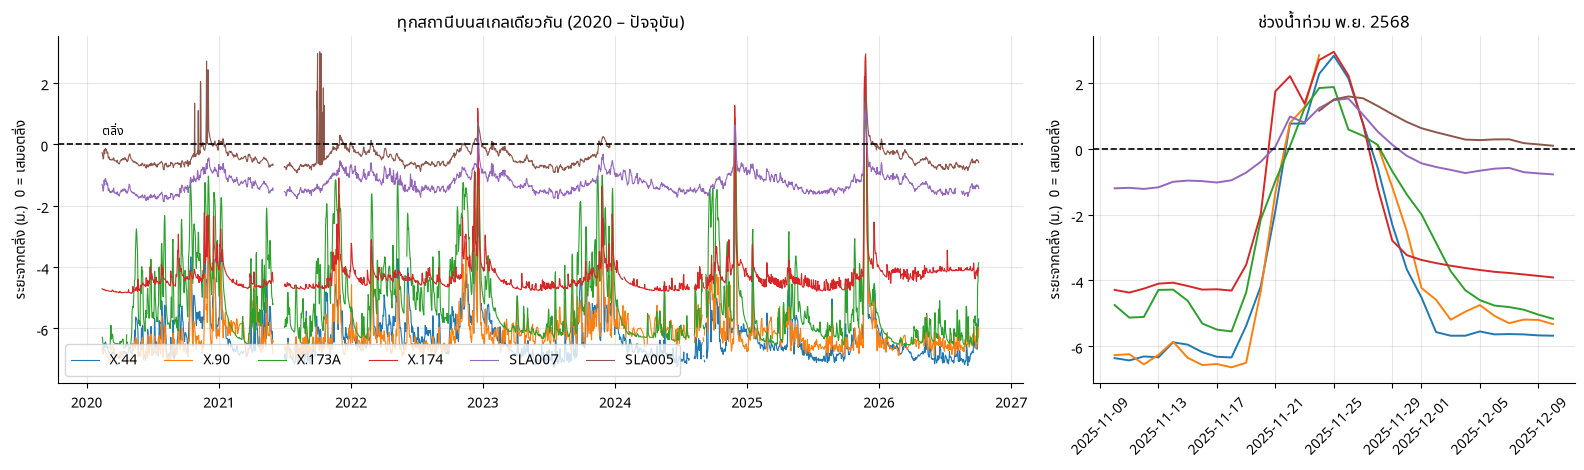

ระยะจากตลิ่งสูงสุดช่วงน้ำท่วม (ม.): {'x44_bank': 2.82, 'x90_bank': 2.84, 'x173a_bank': 1.87, 'x174_bank': 2.94, 'sla007_bank': 1.52, 'sla005_bank': 1.59}


In [6]:
event = slice("2025-11-10", "2025-12-10")
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), gridspec_kw={"width_ratios": [2, 1]})
for station in STATIONS:
    for ax in axes:
        part = table[f"{minimal.prefix(station)}_bank"]
        part = part.loc[event] if ax is axes[1] else part
        ax.plot(part.index, part, lw=1.4 if ax is axes[1] else 0.8,
                label=station if ax is axes[0] else None)
for ax in axes:
    ax.axhline(0, color="k", lw=1.2, ls="--")
    ax.set_ylabel("ระยะจากตลิ่ง (ม.)  0 = เสมอตลิ่ง")
axes[0].text(table.index[0], 0.3, "ตลิ่ง", fontsize=9)
axes[0].set_title("ทุกสถานีบนสเกลเดียวกัน (2020 – ปัจจุบัน)")
axes[1].set_title("ช่วงน้ำท่วม พ.ย. 2568")
axes[1].tick_params(axis="x", rotation=45)
axes[0].legend(ncol=6, loc="lower left")
plt.tight_layout()
plt.show()

peak = table.loc[event].max().filter(like="_bank").round(2)
print("ระยะจากตลิ่งสูงสุดช่วงน้ำท่วม (ม.):", peak.to_dict())

ช่วงน้ำท่วม พ.ย. 2568 สถานีต้นน้ำล้นตลิ่งก่อนแล้ว X.44 กลางเมืองตามมา — ข้อมูลแบบนี้คือสิ่งที่ LSTM ต้องเรียนรู้

สัดส่วนวันที่ขาดของแต่ละสถานีต่อปี (ค่ารายวันว่างเมื่อวันนั้นมีข้อมูล < 12 ชม.) — วันที่ขาดจะถูกเติมด้วยค่าเฉลี่ยของ train
ตอนป้อนเข้าโมเดล (`lstm.Scaler`)

In [7]:
missing = table.filter(like="_bank").isna().groupby(table.index.year).mean().mul(100).round(0)
missing.rename_axis("ปี").rename(columns=lambda c: c.replace("_bank", "")).astype(int).astype(str) + " %"

,x44,x90,x173a,x174,sla007,sla005
ปี,,,,,,
2020,0 %,0 %,0 %,0 %,0 %,0 %
2021,8 %,8 %,8 %,8 %,8 %,8 %
2022,0 %,0 %,0 %,0 %,0 %,0 %
2023,0 %,0 %,0 %,0 %,0 %,4 %
2024,5 %,5 %,5 %,6 %,0 %,100 %
2025,0 %,1 %,0 %,0 %,0 %,90 %
2026,0 %,0 %,0 %,0 %,5 %,0 %


## 4 · ฝนลุ่มน้ำรายวัน (ERA5)
(`minimal.add_rain`) เฉลี่ยฝนรายชั่วโมงของ 6 จุดกริด → รวมเป็นรายวัน (มม.)

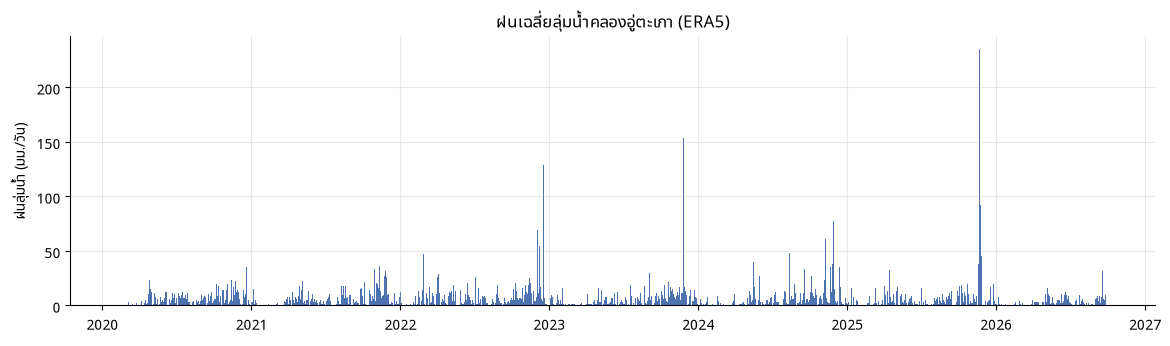

In [8]:
table = minimal.add_rain(table, era5)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(table.index, table["rain"], width=1, color="#4c72b0")
ax.set_ylabel("ฝนลุ่มน้ำ (มม./วัน)")
ax.set_title("ฝนเฉลี่ยลุ่มน้ำคลองอู่ตะเภา (ERA5)")
plt.show()

## 5 · Target: ระดับน้ำ X.44 ล่วงหน้า 1–5 วัน
- `target_h{h}` = ระดับน้ำสูงสุดของ X.44 ในวัน t+h (ม.รทก.)
- `target_delta_h{h}` = target − ระดับวันนี้ = **น้ำจะขึ้น/ลงเท่าไร** — LSTM ทำนายค่านี้แล้วบวกระดับวันนี้กลับ
  เหตุผลอยู่ในหัวข้อ 8
- `minimal.add_targets` สร้าง `era5_rain_next{h}d` (ฝนที่ตกจริงวัน t+1…t+h) ไปพร้อมกันด้วย ใช้ในหัวข้อ 7 และ 9

In [9]:
table = minimal.add_targets(table)

table[["x44_max", "target_h1", "target_delta_h1", "target_h5", "target_delta_h5"]].loc["2025-11-18":"2025-11-26"].round(2)

,x44_max,target_h1,target_delta_h1,target_h5,target_delta_h5
timestamp,,,,,
2025-11-18,0.81,1.77,0.96,7.91,7.10
2025-11-19,1.77,2.97,1.20,9.42,7.65
2025-11-20,2.97,5.26,2.29,9.97,7.00
2025-11-21,5.26,7.91,2.65,9.28,4.03
2025-11-22,7.91,7.91,0.00,7.90,-0.01
2025-11-23,7.91,9.42,1.51,6.58,-1.34
2025-11-24,9.42,9.97,0.55,4.84,-4.58
2025-11-25,9.97,9.28,-0.69,3.48,-6.49
2025-11-26,9.28,7.90,-1.38,2.63,-6.66


## 6 · แบ่ง train / validation / test ตามเวลา
- **train** 2020-02 → 2024-12 · **validation** ม.ค. → ก.ย. 2568 · **test** ต.ค. 2568 → ปัจจุบัน (มีน้ำท่วม พ.ย. 2568)
- ไม่สุ่ม เพราะวันติดกันคล้ายกันมาก ถ้าสุ่ม โมเดลจะได้เห็นวันข้างๆ ของวันที่ทดสอบ แล้วผลดูดีเกินจริง
- validation ใช้ตัดสินว่าจะหยุดเทรนเมื่อไร (early stopping) · test ใช้วัดผลครั้งเดียวตอนจบ

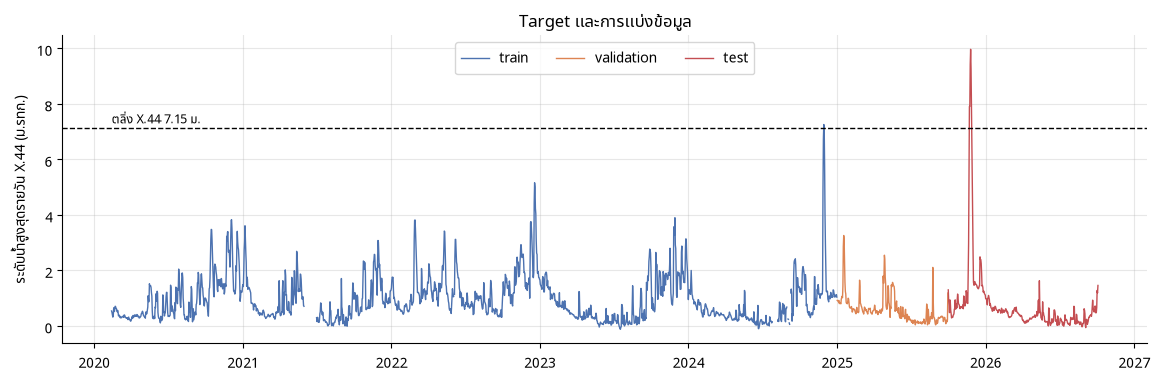

,เริ่ม,ถึง,จำนวนวัน,ระดับสูงสุด,วันน้ำหลาก ≥ 4 ม.,วันล้นตลิ่ง,สัดส่วน %
split,,,,,,,
train,2020-02-13,2024-12-31,1734,7.26,11,1,73.0
validation,2025-01-01,2025-09-30,273,3.26,0,0,11.0
test,2025-10-01,2026-10-04,369,9.97,9,6,16.0


In [10]:
table = minimal.add_split(table)

fig, ax = plt.subplots(figsize=(14, 4))
for split, color in SPLIT_COLORS.items():
    part = table.loc[table["split"] == split, "x44_max"]
    ax.plot(part.index, part, color=color, lw=1, label=split)
ax.axhline(X44_BANK, color="k", ls="--", lw=1)
ax.text(table.index[0], X44_BANK + 0.15, f"ตลิ่ง X.44 {X44_BANK} ม.", fontsize=9)
ax.set_ylabel("ระดับน้ำสูงสุดรายวัน X.44 (ม.รทก.)")
ax.set_title("Target และการแบ่งข้อมูล")
ax.legend(loc="upper center", ncol=3)
plt.show()

known = table.dropna(subset=["x44_max"])
summary = known.groupby("split").agg(**{
    "เริ่ม": ("x44_max", lambda s: s.index.min().date()),
    "ถึง": ("x44_max", lambda s: s.index.max().date()),
    "จำนวนวัน": ("x44_max", "size"),
    "ระดับสูงสุด": ("x44_max", "max"),
    "วันน้ำหลาก ≥ 4 ม.": ("x44_max", lambda s: int((s >= 4).sum())),
    "วันล้นตลิ่ง": ("x44_max", lambda s: int((s >= X44_BANK).sum())),
}).loc[["train", "validation", "test"]]
summary["สัดส่วน %"] = (100 * summary["จำนวนวัน"] / summary["จำนวนวัน"].sum()).round(0)
summary

## 7 · EDA: เลือก input อย่างไร
ใช้ **เฉพาะชุด train** (ถ้าดู test ด้วย = แอบดูข้อสอบก่อนเลือก input) วัดด้วย Pearson correlation (r)
- r ใกล้ 1 = ขึ้นลงไปด้วยกัน · ใกล้ 0 = ไม่สัมพันธ์เชิงเส้น · ติดลบ = สวนทางกัน
- correlation ของระดับน้ำ (ม.รทก.) เท่ากับของระยะจากตลิ่ง เพราะต่างกันแค่ค่าคงที่ จึงเทียบได้ทั้ง 9 สถานี

### 7.1 Correlation matrix ของ input ที่เป็นไปได้

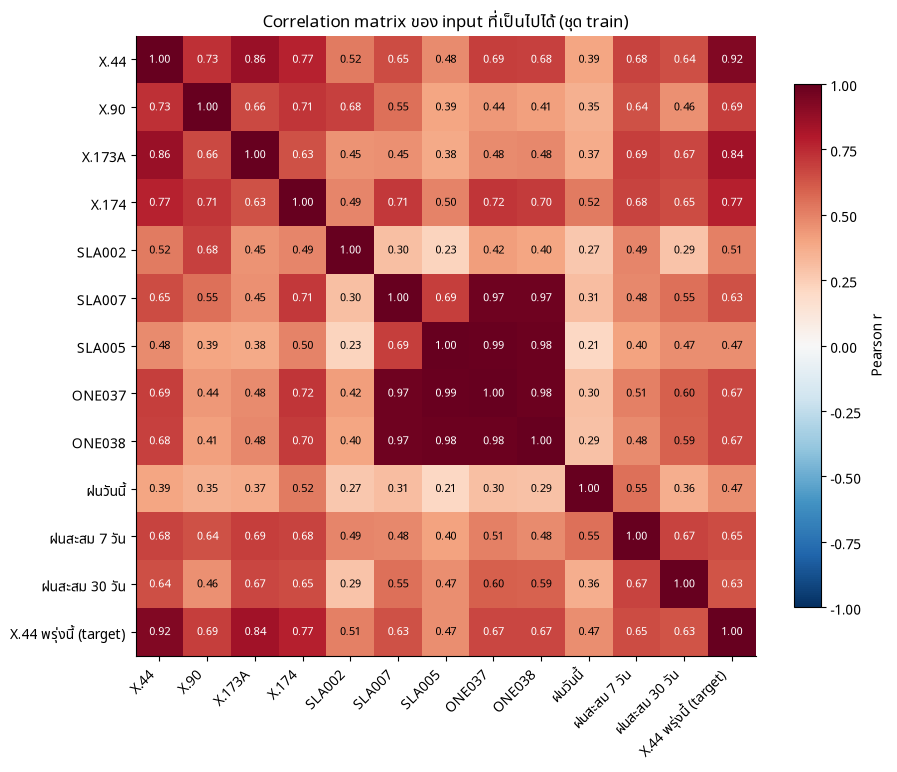

,r กับ X.44 พรุ่งนี้,มีข้อมูลใน train (%)
station_code,,
X.44,0.92,97.20
X.90,0.69,97.20
X.173A,0.84,97.20
X.174,0.77,97.03
SLA002,0.51,97.76
SLA007,0.63,98.26
SLA005,0.47,76.96
ONE037,0.67,38.62
ONE038,0.67,43.39


In [11]:
train = table["split"] == "train"


def corr_heatmap(ax, matrix, title):
    """Annotated correlation heatmap on a fixed −1…1 scale."""
    image = ax.imshow(matrix.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(matrix.shape[1]), matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(matrix.shape[0]), matrix.index)
    ax.grid(False)
    for (i, j), value in numpy.ndenumerate(matrix.to_numpy()):
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 0.6 else "black")
    ax.set_title(title)
    return image


# ระดับน้ำสูงสุดรายวันของทั้ง 9 สถานี + ฝน + target (พรุ่งนี้)
enough_hours = hourly_all.notna().resample("D").sum() >= features.MIN_HOURS_PER_DAY
candidates = hourly_all.resample("D").max().where(enough_hours).reindex(table.index)[ALL_STATIONS]
candidates["ฝนวันนี้"] = table["rain"]
candidates["ฝนสะสม 7 วัน"] = table["rain"].rolling(7).sum()
candidates["ฝนสะสม 30 วัน"] = table["rain"].rolling(30).sum()
candidates["X.44 พรุ่งนี้ (target)"] = table["target_h1"]

fig, ax = plt.subplots(figsize=(10, 8.5))
image = corr_heatmap(ax, candidates[train].corr(), "Correlation matrix ของ input ที่เป็นไปได้ (ชุด train)")
fig.colorbar(image, ax=ax, shrink=0.8, label="Pearson r")
plt.show()

pandas.DataFrame({
    "r กับ X.44 พรุ่งนี้": candidates[train].corr()["X.44 พรุ่งนี้ (target)"],
    "มีข้อมูลใน train (%)": candidates[train].notna().mean() * 100,
}).drop("X.44 พรุ่งนี้ (target)").round(2)

**เลือก 6 สถานี เพราะ**
- **X.44, X.173A, X.174, X.90** (ต้นน้ำ → กลางเมือง) สัมพันธ์กับระดับพรุ่งนี้สูงสุด (r 0.69–0.92)
- **SLA007, SLA005** (ปลายน้ำ / ทะเลสาบ) r ต่ำกว่า (0.47–0.63) แต่เป็นตัวแทนน้ำในทะเลสาบที่ระบายช้า → เก็บไว้ให้โมเดลตัดสิน
- **ไม่ใช้ SLA002** — อยู่จุดเดียวกับ X.90 (พิกัดและตลิ่งเท่ากัน) แต่ r กับ X.44 แค่ 0.51 และมีค่า 999999 จำนวนมาก
- **ไม่ใช้ ONE037 / ONE038** — มีข้อมูลแค่ ~40 % ของ train และซ้ำซ้อนกับ SLA007 / SLA005 (r 0.97–0.99)

**ฝน:** ฝนวันนี้ r แค่ 0.47 แต่ฝนสะสม 7–30 วัน r 0.63–0.65 → น้ำขึ้นกับฝนที่สะสมหลายวัน
จึงป้อนฝนรายวันเป็นลำดับให้ LSTM สะสมเอง แทนการป้อนค่าฝนวันเดียว

### 7.2 input × target: อะไรบอก "ระดับ" อะไรบอก "การเปลี่ยนแปลง"

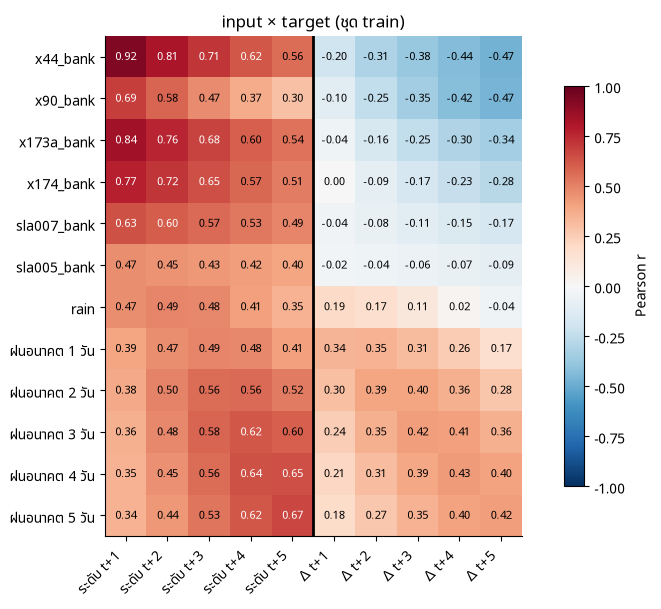

In [12]:
rows = minimal.FEATURES + [f"era5_rain_next{h}d" for h in HORIZONS]
columns = [f"target_h{h}" for h in HORIZONS] + [f"target_delta_h{h}" for h in HORIZONS]
matrix = table.loc[train, rows + columns].corr().loc[rows, columns]
matrix.index = minimal.FEATURES + [f"ฝนอนาคต {h} วัน" for h in HORIZONS]
matrix.columns = [f"ระดับ t+{h}" for h in HORIZONS] + [f"Δ t+{h}" for h in HORIZONS]

fig, ax = plt.subplots(figsize=(11, 6.5))
image = corr_heatmap(ax, matrix, "input × target (ชุด train)")
ax.axvline(4.5, color="k", lw=2)
fig.colorbar(image, ax=ax, shrink=0.8, label="Pearson r")
plt.show()

- **ซ้าย (ระดับ t+h):** ระดับน้ำวันนี้บอกระดับพรุ่งนี้ได้ดีมาก (X.44 r 0.92) แต่ยิ่งไกลยิ่งลดลง (t+5 r 0.56)
- **ขวา (Δ = น้ำจะขึ้น/ลงเท่าไร):** ระดับน้ำวันนี้แทบไม่บอกการเปลี่ยนแปลง (r ≤ 0 = น้ำสูงมักลดลง)
  แต่ **ฝนอนาคต** สัมพันธ์เป็นบวก (ฝน h วันกับ Δ t+h r 0.34–0.43) → การทำนาย "น้ำจะขึ้นอีกเท่าไร" ต้องมีพยากรณ์ฝน
- ฝนอนาคตยิ่งรวมหลายวัน ยิ่งสัมพันธ์กับระดับวันไกลๆ (ฝน 5 วันกับระดับ t+5 r 0.67) → ป้อนฝนรวม t+1…t+h แยกทุก h

### 7.3 ควรมองย้อนหลังกี่วัน

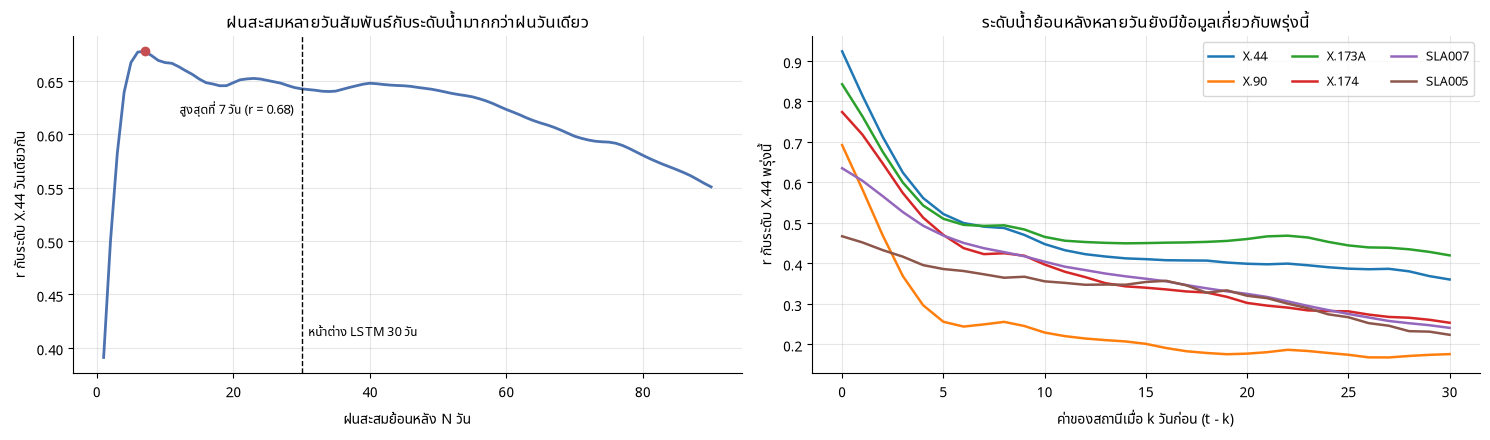

In [13]:
x44_train = table.loc[train, "x44_max"]
windows = numpy.arange(1, 91)
rain_corr = numpy.array([table["rain"].rolling(n).sum()[train].corr(x44_train) for n in windows])
best = windows[rain_corr.argmax()]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(windows, rain_corr, color="#4c72b0", lw=2)
axes[0].axvline(30, color="k", ls="--", lw=1)
axes[0].text(31, rain_corr.min() + 0.02, "หน้าต่าง LSTM 30 วัน", fontsize=9)
axes[0].scatter([best], [rain_corr.max()], color="#c44e52", zorder=3)
axes[0].annotate(f"สูงสุดที่ {best} วัน (r = {rain_corr.max():.2f})", (best, rain_corr.max()),
                 xytext=(25, -45), textcoords="offset points", fontsize=9)
axes[0].set_xlabel("ฝนสะสมย้อนหลัง N วัน")
axes[0].set_ylabel("r กับระดับ X.44 วันเดียวกัน")
axes[0].set_title("ฝนสะสมหลายวันสัมพันธ์กับระดับน้ำมากกว่าฝนวันเดียว")

lags = numpy.arange(0, 31)
for station in STATIONS:
    column = f"{minimal.prefix(station)}_bank"
    lagged = [table[column].shift(k)[train].corr(table.loc[train, "target_h1"]) for k in lags]
    axes[1].plot(lags, lagged, lw=1.8, label=station)
axes[1].set_xlabel("ค่าของสถานีเมื่อ k วันก่อน (t − k)")
axes[1].set_ylabel("r กับระดับ X.44 พรุ่งนี้")
axes[1].set_title("ระดับน้ำย้อนหลังหลายวันยังมีข้อมูลเกี่ยวกับพรุ่งนี้")
axes[1].legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

- ฝนสะสม **7 วัน** สัมพันธ์สูงสุด และยังสูงอยู่จนถึง ~45 วัน (ดินอุ้มน้ำไว้หลายสัปดาห์) แล้วค่อยลดลง
- ระดับน้ำย้อนหลังลด r เร็วใน 5 วันแรก แต่ยังคงที่ ~0.2–0.45 อีกหลายสัปดาห์ (สภาพน้ำของทั้งฤดู)
- → **หน้าต่าง 30 วัน** ครอบคลุมช่วงที่ฝนสะสมยังสัมพันธ์สูง โดยไม่ยาวจนตัวอย่าง train ลดลงมาก (แต่ละตัวอย่างต้องมีข้อมูลย้อนหลังครบ)

### 7.4 ข้อมูลไม่สมดุล

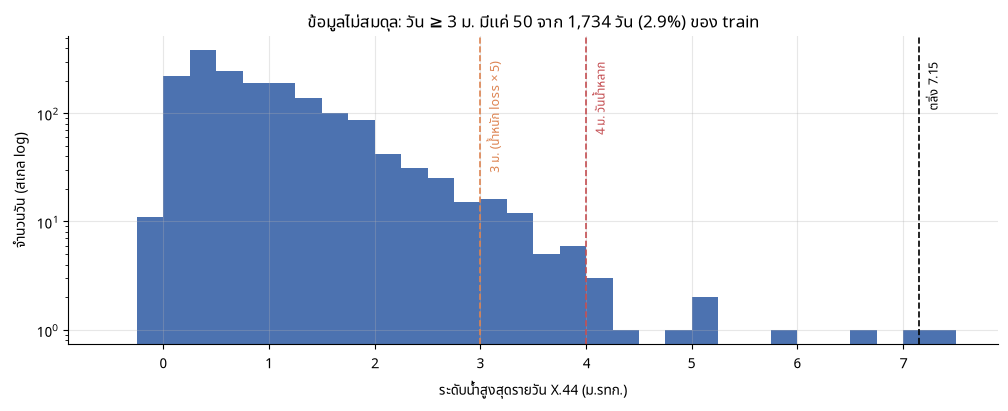

In [14]:
train_level = table.loc[train, "x44_max"].dropna()
high_days = int((train_level >= 3).sum())

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(train_level, bins=numpy.arange(-0.5, 7.75, 0.25), color="#4c72b0")
ax.set_yscale("log")
for level, label, color in [(3, "3 ม. (น้ำหนัก loss × 5)", "#dd8452"), (4, "4 ม. วันน้ำหลาก", "#c44e52"),
                            (X44_BANK, "ตลิ่ง 7.15", "k")]:
    ax.axvline(level, color=color, ls="--", lw=1.2)
    ax.text(level + 0.05, 300, label, color=color, fontsize=9, rotation=90, va="top")
ax.set_xlabel("ระดับน้ำสูงสุดรายวัน X.44 (ม.รทก.)")
ax.set_ylabel("จำนวนวัน (สเกล log)")
ax.set_title(f"ข้อมูลไม่สมดุล: วัน ≥ 3 ม. มีแค่ {high_days} จาก {len(train_level):,} วัน "
             f"({100 * high_days / len(train_level):.1f}%) ของ train")
plt.show()

ถ้าให้ทุกวันมีน้ำหนักเท่ากัน loss ถูกกำหนดโดยวันน้ำปกติเกือบทั้งหมด → LSTM ใช้ **weighted MSE** ที่วัน ≥ 3 ม. มีน้ำหนัก 5 เท่า

### สรุปการตัดสินใจจาก EDA
| การตัดสินใจ | หลักฐาน |
|---|---|
| ใช้ 6 สถานี (ตัด SLA002, ONE037, ONE038) | 7.1: r กับ target, ความครบ, ความซ้ำซ้อน |
| ป้อนฝนรายวันเป็นลำดับ ไม่ใช่ฝนวันเดียว | 7.1, 7.3: ฝนสะสม r สูงกว่าฝนวันเดียว |
| หน้าต่างย้อนหลัง 30 วัน | 7.3: ฝนสะสมยังสัมพันธ์สูงถึง ~45 วัน |
| ทำนาย Δ และเพิ่มพยากรณ์ฝน t+1…t+h | 7.2: ระดับวันนี้ไม่บอก Δ แต่ฝนอนาคตบอก (และหัวข้อ 8) |
| weighted loss วัน ≥ 3 ม. × 5 | 7.4: วันน้ำสูงมีไม่ถึง 3 % |

## 8 · ปัญหา: test มีน้ำสูงกว่าทุกอย่างที่ train เคยเห็น
- train สูงสุด **7.26 ม.** (ปี 2567) แต่ test พีค **9.97 ม.**
- ถ้าให้โมเดลทำนายระดับน้ำตรงๆ โมเดลมักทำนายไม่เกินช่วงที่เคยเห็น
- **ทางแก้:** ทำนาย "น้ำจะขึ้นอีกเท่าไรจากวันนี้" (`target_delta`) แล้วบวกระดับวันนี้กลับ
  วันที่ 24 พ.ย. 2568 น้ำอยู่ที่ ~9 ม. แล้ว โมเดลแค่ต้องทำนายว่าจะขึ้นอีก ~1 ม.
- **ข้อจำกัดที่ต้องรู้:** validation (ม.ค.–ก.ย. 2568) **ไม่มีวันน้ำหลากเลย** early stopping จึงตัดสินจากวันน้ำปกติเป็นหลัก

## 9 · ฝนอนาคต t+1 … t+h
ฝนที่จะตกในอีกไม่กี่วันข้างหน้าสำคัญมาก เพราะน้ำจากต้นน้ำมาถึงเมืองก่อนแค่ไม่ถึง 1 วัน
ถ้าไม่รู้ฝนล่วงหน้า ทำนาย 3–5 วันได้แค่ "เท่าวันนี้"

| ช่วง | ฝนอนาคตที่ป้อนให้โมเดล | เหตุผล |
|---|---|---|
| train (2563–2567) | ฝน **ERA5 ที่ตกจริง** | พยากรณ์ย้อนหลังมีแค่ตั้งแต่ มี.ค. 2567 ไม่พอเทรน ("perfect prognosis") |
| validation, test | **พยากรณ์ GFS** × ตัวคูณแก้ bias | เหมือนการใช้งานจริง |

- ใช้พยากรณ์ที่ออก **เก่ากว่า 1 วัน** (`FORECAST_LEAD_OFFSET`) เพราะตอนสิ้นวัน t พยากรณ์รอบล่าสุดอาจยังไม่ออก
- GFS ให้ฝนน้อยกว่าจริง → คูณด้วย (ฝนจริงรวม / ฝนพยากรณ์รวม) ช่วง มี.ค.–ธ.ค. 2567 ซึ่งอยู่ใน train จึงไม่ได้แอบดู test

In [15]:
# พยากรณ์ GFS ฝนรวมวัน t+1..t+h (ยังไม่แก้ bias) → gfs_raw_rain_next{h}d
nwp_daily = features.nwp_daily_rain(nwp_rain)
table = minimal.add_gfs_rain(table, nwp_daily)

# ตัวคูณ = ฝนจริงรวม / ฝนพยากรณ์รวม ช่วง มี.ค.–ธ.ค. 2567
SCALE = minimal.gfs_bias_scale(table)
pandas.Series(SCALE, name="ตัวคูณแก้ bias GFS").rename_axis("h").round(2).to_frame().T

h,1,2,3,4,5
ตัวคูณแก้ bias GFS,1.35,1.38,1.38,1.58,1.75


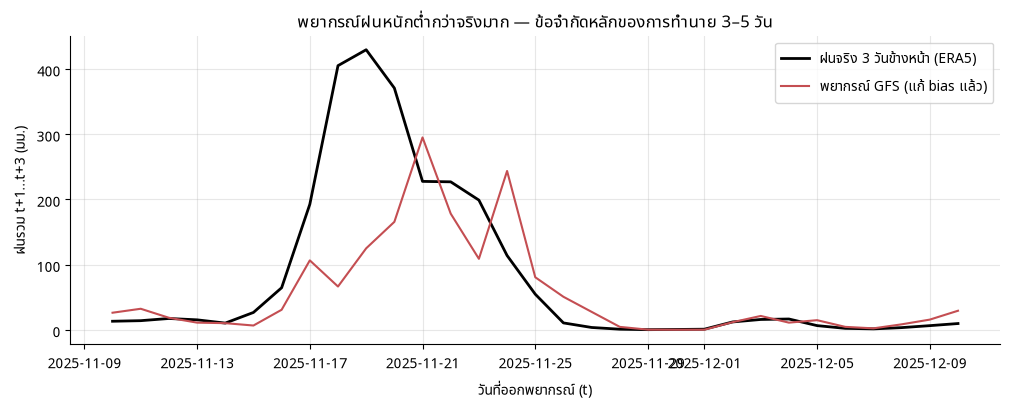

In [16]:
# gfs_rain_next = พยากรณ์ × ตัวคูณ; rain_next (input โมเดล) = ERA5 ใน train, GFS นอก train
table = minimal.add_rain_next(table, SCALE)

# พยากรณ์ 3 วันเทียบฝนจริง ช่วงน้ำท่วม
fig, ax = plt.subplots(figsize=(12, 4))
part = table.loc[event]
ax.plot(part.index, part["era5_rain_next3d"], color="k", lw=2, label="ฝนจริง 3 วันข้างหน้า (ERA5)")
ax.plot(part.index, part["gfs_rain_next3d"], color="#c44e52", lw=1.5, label="พยากรณ์ GFS (แก้ bias แล้ว)")
ax.set_ylabel("ฝนรวม t+1…t+3 (มม.)")
ax.set_xlabel("วันที่ออกพยากรณ์ (t)")
ax.set_title("พยากรณ์ฝนหนักต่ำกว่าจริงมาก — ข้อจำกัดหลักของการทำนาย 3–5 วัน")
ax.legend()
plt.show()

## 10 · ตารางสุดท้าย → `data/processed/minimal_daily.parquet`

In [17]:
FEATURES, RAIN_NEXT = minimal.FEATURES, minimal.RAIN_NEXT

table.to_parquet(PROCESSED / "minimal_daily.parquet")
print(f"{len(table):,} วัน ({table.index.min():%Y-%m-%d} ถึง {table.index.max():%Y-%m-%d})")
print(f"input ต่อวัน ({len(FEATURES)}):", FEATURES)
print("ฝนอนาคต:", RAIN_NEXT)
print("target:", [f"target_h{h}" for h in HORIZONS])
table[FEATURES + RAIN_NEXT + ["x44_max", "target_h1", "split"]].loc["2025-11-20":"2025-11-25"].round(2)

2,426 วัน (2020-02-13 ถึง 2026-10-04)
input ต่อวัน (7): ['x44_bank', 'x90_bank', 'x173a_bank', 'x174_bank', 'sla007_bank', 'sla005_bank', 'rain']
ฝนอนาคต: ['rain_next1d', 'rain_next2d', 'rain_next3d', 'rain_next4d', 'rain_next5d']
target: ['target_h1', 'target_h2', 'target_h3', 'target_h4', 'target_h5']


,x44_bank,x90_bank,x173a_bank,x174_bank,sla007_bank,sla005_bank,rain,rain_next1d,rain_next2d,rain_next3d,rain_next4d,rain_next5d,x44_max,target_h1,split
timestamp,,,,,,,,,,,,,,,
2025-11-20,-4.18,-4.33,-2.15,-1.99,-0.40,NaN,131.57,18.28,42.03,165.53,194.44,222.68,2.97,5.26,test
2025-11-21,-1.89,-1.34,-0.98,1.74,0.06,NaN,235.33,41.73,188.42,295.05,360.18,404.56,5.26,7.91,test
2025-11-22,0.76,0.78,0.07,2.20,0.97,NaN,62.67,112.21,144.48,178.12,213.03,242.87,7.91,7.91,test
2025-11-23,0.76,1.26,1.23,1.37,0.79,NaN,72.80,41.59,81.61,108.83,149.46,167.67,7.91,9.42,test
2025-11-24,2.27,2.84,1.84,2.69,1.23,1.15,92.15,100.25,121.70,243.59,279.13,310.66,9.42,9.97,test
2025-11-25,2.82,NaN,1.87,2.94,1.47,1.49,62.00,63.28,77.80,80.57,96.58,108.61,9.97,9.28,test
